## <center> Prelims 2023
### <center> Mani Tyagi
#### <center> 200973108

In [34]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


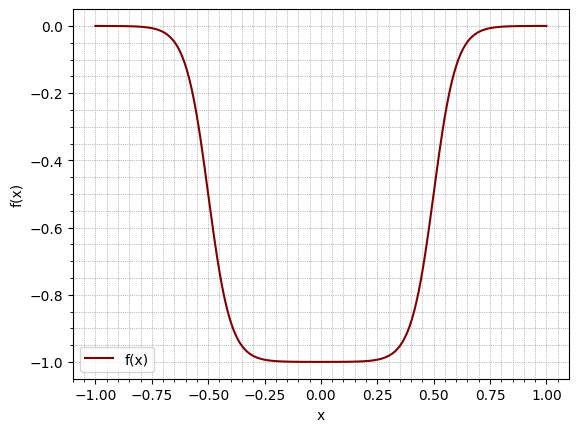

In [35]:
def f(x):
    return (np.tanh(10*x - 5) - np.tanh(10*x+5))/2

# plotting the function
x = np.linspace(-1,1,400)
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()

### Part (a)

In [36]:
def legendre_polynomial(n, x):
    if n == 0:
        return 1
    elif n == 1:
        return x
    elif n == 2:
        return 0.5 * (3*x**2 - 1)
    elif n == 3:
        return 0.5 * (5*x**3 - 3*x)
    elif n == 4:
        return (1/8.0) * (35*x**4 - 30*x**2 + 3)
    else:
        return ((2*n - 1) * x * legendre_polynomial(n-1, x) - (n - 1) * legendre_polynomial(n-2, x)) / n


# function to calculate coefficients
def coefficients(n, x, f):
    # Define the integrand as a function of x
    def integrand(x):
        return f(x) * legendre_polynomial(n, x)
    
    # Perform the integration over the interval [-1, 1]
    I, _ = quad(integrand, -1, 1)
    
    return ((2*n+1)/2.0) * I
    
# function to print the coefficients    
def print_coefficients(max_n, f):
    for n in range(max_n+1):
        c = coefficients(n, x, f)
        print(f"Coefficient c{n}: {c}")
        
print_coefficients(4, f)        

Coefficient c0: -0.4999977300550438
Coefficient c1: 0.0
Coefficient c2: 0.9066706235738025
Coefficient c3: 0.0
Coefficient c4: -0.4750742250806061


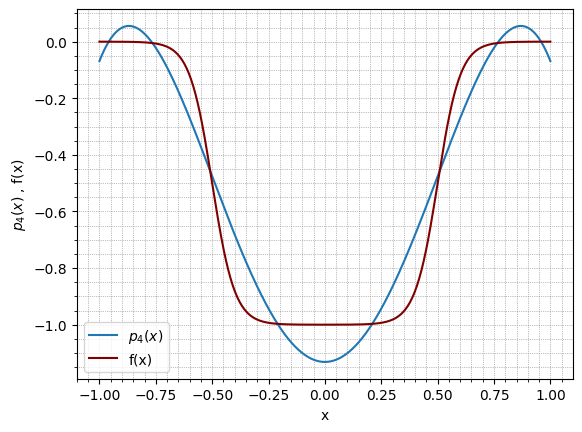

In [37]:
def construct_Pn(n, f):
    # Compute the coefficients c_i for i in range(n+1)
    coeffs = [coefficients(i, x, f) for i in range(n+1)]
    
    # Define the polynomial function Pn(x)
    def Pn(x):
        return sum(c * legendre_polynomial(i, x) for i, c in enumerate(coeffs))
    
    return Pn

# Construct P4(x) 
Pn_function = construct_Pn(4, f)

# Generate x values and compute P4(x) values
x_values = np.linspace(-1, 1, 400)
Pn_values = [Pn_function(x) for x in x_values]

# Plot P4(x)
plt.plot(x_values, Pn_values, label="$p_4(x)$")
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('$p_4(x)$ , f(x)')
plt.xlabel('x')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

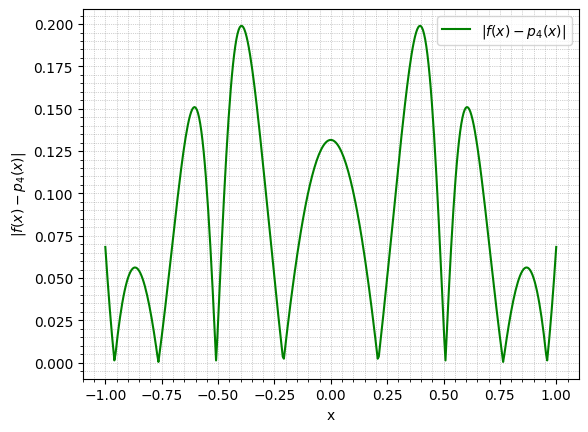

In [38]:

plt.plot(x, abs(f(x)-Pn_values),color='green',label='$|f(x)-p_4(x)|$')
plt.xlabel('x')
plt.ylabel('$|f(x)-p_4(x)|$')
plt.xlabel('x')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()

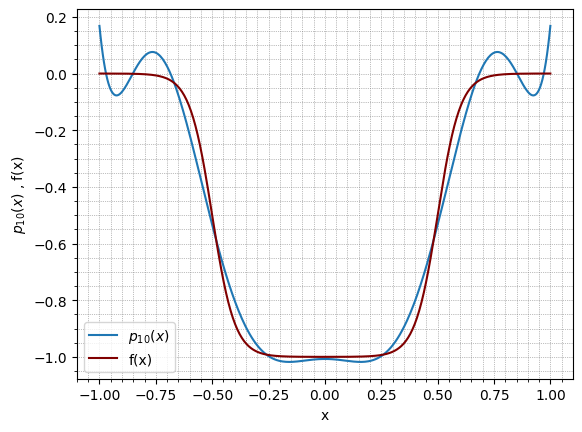

In [39]:
# Construct P4(x) for the example function
Pn_function = construct_Pn(8, f)

# Generate x values and compute P10(x) values
x_values = np.linspace(-1, 1, 400)
Pn_values = [Pn_function(x) for x in x_values]

# Plot P10(x)
plt.plot(x_values, Pn_values, label="$p_{10}(x)$")
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('$p_{10}(x)$ , f(x)')
plt.xlabel('x')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

## Part (c)

In [48]:
# Calculate the coefficient for the nth basis function
def coefficient(n, f):
    if n == 0:
        integrand = lambda x: f(x)
        I, _ = quad(integrand, -1, 1)
        return I / 2  # Normalize for the constant term
    elif n % 2 == 1:  # odd index, sine
        k = (n // 2) + 1
        integrand = lambda x: f(x) * np.sin(k * np.pi * x)
        I, _ = quad(integrand, -1, 1)
        return I
    else:  # even index, cosine
        k = n // 2
        integrand = lambda x: f(x) * np.cos(k * np.pi * x)
        I, _ = quad(integrand, -1, 1)
        return I

# Define the number of terms to include in the Fourier series
n_terms = 4

# Calculate coefficients
coefficients = [coefficient(n, f) for n in range(2 * n_terms + 1)]

# Reconstruct the function using the Fourier series
def f_approx(x, coefficients):
    result = coefficients[0]
    for n in range(1, len(coefficients)):
        if n % 2 == 1:  # sine term
            k = (n // 2) + 1
            result += coefficients[n] * np.sin(k * np.pi * x)
        else:  # cosine term
            k = n // 2
            result += coefficients[n] * np.cos(k * np.pi * x)
    return result


# Print the calculated coefficients
for i, coeff in enumerate(coefficients):
    print(f"Coefficient c{i}: {coeff}")



Coefficient c0: -0.9999954601100876
Coefficient c1: 0.0
Coefficient c2: -1.2230026939943048
Coefficient c3: 0.0
Coefficient c4: 8.264128177171148e-06
Coefficient c5: 0.0
Coefficient c6: 0.30153640946752147
Coefficient c7: 0.0
Coefficient c8: 6.5097700679001e-06


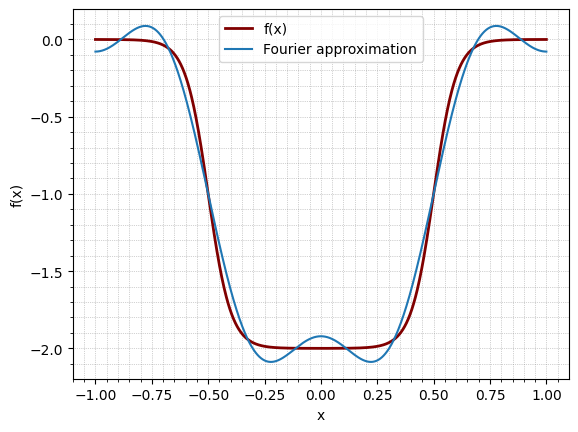

In [49]:
# Generate x values for plotting
x = np.linspace(-1, 1, 1000)

# Calculate the approximate function values
y_approx = f_approx(x, coefficients)

# Plot the original function and its Fourier approximation
plt.plot(x, f(x), label='f(x)', linewidth=2, color='maroon')
plt.plot(x, y_approx, label='Fourier approximation')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()